# Autonomous Social Media Strategy Agent (Postmaker)

An end-to-end agentic workflow that scrapes an article, drafts a multi-platform social media campaign (Twitter/X thread and LinkedIn post), and iteratively self-corrects against strict platform constraints using custom validation tools.

### Architecture Overview
1. **Source Ingestion:** Web scraper tool extracts cleaned text from a target URL.
2. **Draft Generation:** Groq LLM synthesizes key takeaways into formatted social posts.
3. **Guardrail Validation:** Custom deterministic regex tool checks character limits and hashtag thresholds.
4. **Self-Correction Loop:** LangGraph routes any validation failures back to the agent for targeted revision until platform rules pass.

## 1. Environment Configuration & Model Initialization

Set up the execution environment by securely loading credentials and configuring the language model instance via LangChain's Groq integration.

* **API Key Handling:** Loads `GROQ_API_KEY` from a local `.env` file; falls back to an interactive prompt if the variable is not set.
* **Model Configuration:** Initializes `openai/gpt-oss-safeguard-20b` with a low temperature (`0.2`) to prioritize deterministic schema validation and tool-calling execution.

In [18]:
import os
import getpass
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    groq_api_key = getpass.getpass("Enter your GROQ_API_KEY: ").strip()
    os.environ["GROQ_API_KEY"] = groq_api_key

# Initialize reasoning model for tool calling
llm = ChatGroq(
    model="openai/gpt-oss-safeguard-20b",
    temperature=0.2,  # Low temperature ensures deterministic tool calling & validation
    api_key=os.environ.get("GROQ_API_KEY")
)

print("Groq LLM initialized successfully.")

Groq LLM initialized successfully.


## 2. Tool Definitions for Ingestion & Validation

Define the custom LangChain toolset used by the agent to acquire source material and verify output quality against platform rules.

* **`fetch_webpage_content`:** Extracts the readable core text of an article using BeautifulSoup while stripping boilerplate markup (`<nav>`, `<footer>`, `<script>`). Truncates to 8,000 characters to prevent context window overflow.
* **`validate_social_draft`:** Applies automated guardrails to verify that the generated draft contains at least 3 hashtags and ensures individual tweet segments remain within the 280-character limit.

In [19]:
import re
import requests
from bs4 import BeautifulSoup
from langchain_core.tools import tool

@tool
def fetch_webpage_content(url: str) -> str:
    """Scrapes and extracts the readable body text from a webpage URL."""
    try:
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
        res = requests.get(url, headers=headers, timeout=12)
        res.raise_for_status()

        soup = BeautifulSoup(res.text, "html.parser")
        for tag in soup(["script", "style", "nav", "footer", "header", "aside", "form"]):
            tag.decompose()

        main_content = soup.find("article") or soup.find("main") or soup.body
        text = " ".join(main_content.stripped_strings)
        return text[:8000] if text else "Error: No readable text found."
    except Exception as e:
        return f"Scraping Error: {str(e)}"

@tool
def validate_social_draft(draft_text: str) -> str:
    """
    Validates platform constraints from a full draft text:
    - Checks that individual tweets do not exceed 280 characters.
    - Checks that the draft contains at least 3 hashtags.
    Input should be the complete drafted copy as a single text string.
    """
    failures = []

    # Check for hashtags
    hashtags = re.findall(r"#\w+", draft_text)
    if len(hashtags) < 3:
        failures.append(f"Draft only has {len(hashtags)} hashtag(s). Minimum 3 required.")

    # Check tweet lengths if tweets are numbered (e.g. 1/3, 1., Tweet 1)
    tweet_blocks = re.split(r"(?:Tweet\s*\d+|[1-9]/\d+|(?:\n|^)\d+\.)", draft_text)
    for idx, block in enumerate(tweet_blocks[1:], 1):
        clean_block = block.split("---")[0].strip()
        if len(clean_block) > 280:
            failures.append(f"Tweet chunk #{idx} is {len(clean_block)} characters (max 280 allowed).")

    if not failures:
        return "PASSED: All social platform constraints are satisfied."

    return "FAILED:\n" + "\n".join(failures)

tools = [fetch_webpage_content, validate_social_draft]
print(f"Loaded {len(tools)} tools: {[t.name for t in tools]}")

Loaded 2 tools: ['fetch_webpage_content', 'validate_social_draft']


## 3. Tool Binding & Execution Mapping

Attach the schema of our custom tools to the ChatGroq model and establish an execution dispatch mapping.

* **Schema Binding:** Calls `.bind_tools(tools)` so the LLM receives the function signatures, parameter types, and docstrings necessary to emit structured tool calls.
* **Dispatch Map:** Maps string function names to their callable Python functions in `tool_map` for deterministic execution during the agent loop.

In [20]:
# 1. Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

# 2. Map tool names
tool_map = {
    "fetch_webpage_content": fetch_webpage_content,
    "validate_social_draft": validate_social_draft
}

print("Tools bound successfully.")



Tools bound successfully.


## 4. LangGraph State Machine & Agent Execution

Construct a stateful agent loop using LangGraph that scrapes content, drafts platform-specific copy, and iteratively self-corrects using tool validation.

* **State Schema (`AgentState`):** Uses LangGraph's `add_messages` reducer to accumulate conversational context and tool call history across iterations.
* **Nodes & Routing:**
  * `agent`: Invokes the tool-bound model with current message history.
  * `tools`: Executes invoked tools using LangGraph's prebuilt `ToolNode`.
  * `tools_condition`: Inspects the model output—routes to `tools` if tool calls are requested, or exits to `END` once generation is finalized.
* **Self-Correction Feedback Loop:** Automatically passes validation error output back to the model, prompting it to revise tweet lengths or hashtag counts until the draft passes checks.
* **Execution Guardrail:** Enforces `recursion_limit=12` to prevent runaway recursive calls during self-correction.

In [21]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# ==========================================
# 1. State Definition
# ==========================================
class AgentState(TypedDict):
    # 'add_messages' ensures new messages append rather than overwrite
    messages: Annotated[list[BaseMessage], add_messages]

# ==========================================
# 2. Nodes
# ==========================================
def call_model(state: AgentState):
    """LLM Node: Reads the current message history and generates a response."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# ToolNode dynamically dispatches tool calls to the matching functions in `tools`
tool_node = ToolNode(tools)

# ==========================================
# 3. Graph Construction
# ==========================================
workflow = StateGraph(AgentState)

# Add processing nodes
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Define execution flow
workflow.add_edge(START, "agent")

# tools_condition checks response.tool_calls:
# - If tool_calls exist -> route to "tools"
# - If empty -> route to END
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END
    }
)

# After executing tools, route observations back to the agent node (The Feedback Loop)
workflow.add_edge("tools", "agent")

# Compile into an executable runnable
app = workflow.compile()

# ==========================================
# 4. Invocation
# ==========================================
target_url = "https://en.wikipedia.org/wiki/Gut_microbiota"

system_prompt = (
    "You are an autonomous Social Media Strategy Agent.\n"
    "Workflow:\n"
    "1. Call `fetch_webpage_content` to extract article text.\n"
    "2. Draft a 3-tweet thread (under 280 chars each) and a LinkedIn post with >= 3 hashtags.\n"
    "3. Call `validate_social_draft` passing your draft as a string.\n"
    "4. If validation returns FAILED, adjust your draft and re-validate.\n"
    "5. When PASSED, output the final post directly."
)

initial_messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(content=f"Create and validate social posts for: {target_url}")
]

# recursion_limit replaces your manual max_iterations circuit breaker
final_state = app.invoke(
    {"messages": initial_messages},
    config={"recursion_limit": 12}
)

print("\n" + "=" * 60)
print("FINAL VALIDATED DELIVERABLE")
print("=" * 60)
print(final_state["messages"][-1].content)


FINAL VALIDATED DELIVERABLE
**Tweet Thread**

1️⃣ 10^13–10^14 microbes live in our gut—about 100× more genes than the human genome! These tiny allies shape digestion, immunity, and even our mood. #Microbiome #Health #Science  

2️⃣ Gut flora ferments fiber into short‑chain fatty acids, synthesizes B‑vitamins, modulates bile acids, and signals the brain via the gut‑brain axis. Dysbiosis is linked to IBD, cancer, and neuro‑disorders. #GutHealth #Microbiome  

3️⃣ What steers this microbial metropolis? Diet, age, antibiotics, genetics. A Mediterranean diet fuels beneficial SCFAs; probiotics show promise for CNS conditions. Researchers map enterotypes and build biobanks for personalized therapies. #Nutrition #Probiotics #PrecisionMedicine  

---

**LinkedIn Post**

The human gut hosts an astonishing 10^13–10^14 microorganisms—an ecosystem that outnumbers our own cells and carries 100× more genes than the human genome. This gut microbiota is not a passive passenger; it ferments dietary fib

### Mermaid Diagram 

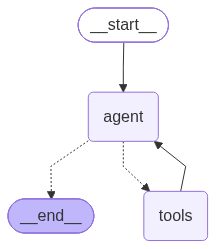

In [22]:
app=workflow.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))